In [ ]:
#Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Read data

cy = pd.read_csv("/content/cyber_crimes.csv", sep='\t')

In [ ]:
cy.shape

(39, 9)

In [ ]:
cy.columns

Index(['S. No', 'Category', 'State/UT', '2016', '2017', '2018',
       'Percentage Share of State/UT (2018)',
       'Mid-Year Projected Population (in Lakhs) (2018)+',
       'Rate of Total Cyber Crimes (2018)++'],
      dtype='object')

In [ ]:
cy.isnull().sum()

,0
S. No,0
Category,0
State/UT,0
2016,0
2017,0
2018,0
Percentage Share of State/UT (2018),0
Mid-Year Projected Population (in Lakhs) (2018)+,0
Rate of Total Cyber Crimes (2018)++,0


In [ ]:
cy.head(10)

,S. No,Category,State/UT,2016,2017,2018,Percentage Share of State/UT (2018),Mid-Year Projected Population (in Lakhs) (2018)+,Rate of Total Cyber Crimes (2018)++
0,1,State,Andhra Pradesh,616,931,1207,4.4,520.3,2.3
1,2,State,Arunachal Pradesh,4,1,7,0.0,14.9,0.5
2,3,State,Assam,696,1120,2022,7.4,340.4,5.9
3,4,State,Bihar,309,433,374,1.4,1183.3,0.3
4,5,State,Chhattisgarh,90,171,139,0.5,284.7,0.5
5,6,State,Goa,31,13,29,0.1,15.3,1.9
6,7,State,Gujarat,362,458,702,2.6,673.2,1.0
7,8,State,Haryana,401,504,418,1.5,284.0,1.5
8,9,State,Himachal Pradesh,31,56,69,0.3,72.7,0.9
9,10,State,Jammu & Kashmir,28,63,73,0.3,134.3,0.5


In [ ]:
cy.tail(10)

,S. No,Category,State/UT,2016,2017,2018,Percentage Share of State/UT (2018),Mid-Year Projected Population (in Lakhs) (2018)+,Rate of Total Cyber Crimes (2018)++
29,State,State,Total State(s),12187,21593,27004,99.1,12997.9,2.1
30,30,Union Territory,A & N Islands,3,3,7,0.0,4.0,1.8
31,31,Union Territory,Chandigarh,26,32,30,0.1,11.7,2.6
32,32,Union Territory,D&N Haveli,1,1,0,0.0,5.3,0.0
33,33,Union Territory,Daman & Diu,0,0,0,0.0,4.0,0.0
34,34,Union Territory,Delhi UT,98,162,189,0.7,195.6,1.0
35,35,Union Territory,Lakshadweep,0,0,4,0.0,0.7,6.0
36,36,Union Territory,Puducherry,2,5,14,0.1,14.8,0.9
37,Union Territory,Union Territory,Total UT(s),130,203,244,0.9,236.0,1.0
38,Total (All India),Total (All India),Total (All India),12317,21796,27248,100.0,13233.8,2.1


In [ ]:
cy.dtypes

,0
S. No,object
Category,object
State/UT,object
2016,int64
2017,int64
2018,int64
Percentage Share of State/UT (2018),float64
Mid-Year Projected Population (in Lakhs) (2018)+,float64
Rate of Total Cyber Crimes (2018)++,float64


In [ ]:
#Rows showing grant totals of statewise count

cy.iloc[[29,37,38]]

,S. No,Category,State/UT,2016,2017,2018,Percentage Share of State/UT (2018),Mid-Year Projected Population (in Lakhs) (2018)+,Rate of Total Cyber Crimes (2018)++
29,State,State,Total State(s),12187,21593,27004,99.1,12997.9,2.1
37,Union Territory,Union Territory,Total UT(s),130,203,244,0.9,236.0,1.0
38,Total (All India),Total (All India),Total (All India),12317,21796,27248,100.0,13233.8,2.1


In [ ]:
#Drop above 3 rows since those are grant totals

cy = cy.drop(index=[29,37,38])

In [ ]:
#Reset index

cy=cy.reset_index()

In [ ]:
#Drop columns

cy = cy.drop(columns=['S. No','index'])

In [ ]:
cy.tail(10)

,Category,State/UT,2016,2017,2018,Percentage Share of State/UT (2018),Mid-Year Projected Population (in Lakhs) (2018)+,Rate of Total Cyber Crimes (2018)++
26,State,Uttar Pradesh,2639,4971,6280,23.0,2230.0,2.8
27,State,Uttarakhand,62,124,171,0.6,110.6,1.5
28,State,West Bengal,478,568,335,1.2,965.0,0.3
29,Union Territory,A & N Islands,3,3,7,0.0,4.0,1.8
30,Union Territory,Chandigarh,26,32,30,0.1,11.7,2.6
31,Union Territory,D&N Haveli,1,1,0,0.0,5.3,0.0
32,Union Territory,Daman & Diu,0,0,0,0.0,4.0,0.0
33,Union Territory,Delhi UT,98,162,189,0.7,195.6,1.0
34,Union Territory,Lakshadweep,0,0,4,0.0,0.7,6.0
35,Union Territory,Puducherry,2,5,14,0.1,14.8,0.9


In [ ]:
#unique values in Category column

cy['Category'].value_counts()

,count
Category,
State,29
Union Territory,7


In [ ]:
#Convertion of Category column as 2 separate columns

cy = pd.concat([cy, pd.get_dummies(cy['Category'],dtype = int)], axis = 1)

cy[['State', 'Union Territory']].head(5)

,State,Union Territory
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0


In [ ]:
#Drop category column

cy = cy.drop(columns = ['Category'])

In [ ]:
cy.dtypes

,0
State/UT,object
2016,int64
2017,int64
2018,int64
Percentage Share of State/UT (2018),float64
Mid-Year Projected Population (in Lakhs) (2018)+,float64
Rate of Total Cyber Crimes (2018)++,float64
State,int64
Union Territory,int64


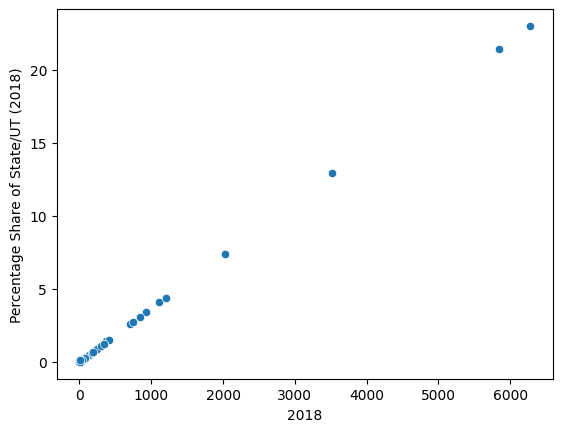

In [ ]:
#Relation between 2018 crime count & Percentage Share of State/UT (2018)

sns.scatterplot(data=cy, x='2018', y='Percentage Share of State/UT (2018)')
plt.show()

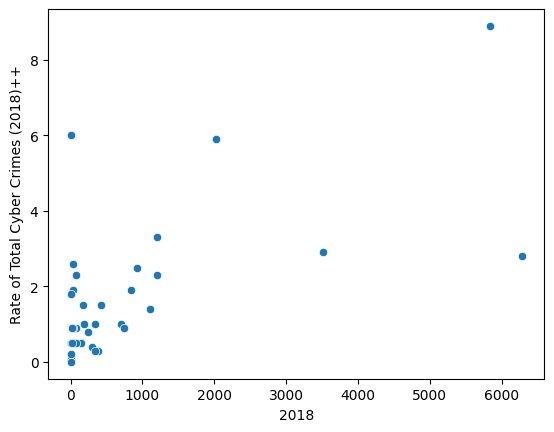

In [ ]:
#Relation between 2018 crime count & Rate of Total Cyber Crimes (2018)++

sns.scatterplot(data=cy, x='2018', y='Rate of Total Cyber Crimes (2018)++')
plt.show()

In [ ]:
#Correlation

col_list = ['2018','Percentage Share of State/UT (2018)','Mid-Year Projected Population (in Lakhs) (2018)+','Rate of Total Cyber Crimes (2018)++']
corr = cy[col_list].corr()
corr

,2018,Percentage Share of State/UT (2018),Mid-Year Projected Population (in Lakhs) (2018)+,Rate of Total Cyber Crimes (2018)++
2018,1.000000,0.999989,0.724852,0.633553
Percentage Share of State/UT (2018),0.999989,1.000000,0.725222,0.632999
Mid-Year Projected Population (in Lakhs) (2018)+,0.724852,0.725222,1.000000,0.151820
Rate of Total Cyber Crimes (2018)++,0.633553,0.632999,0.151820,1.000000


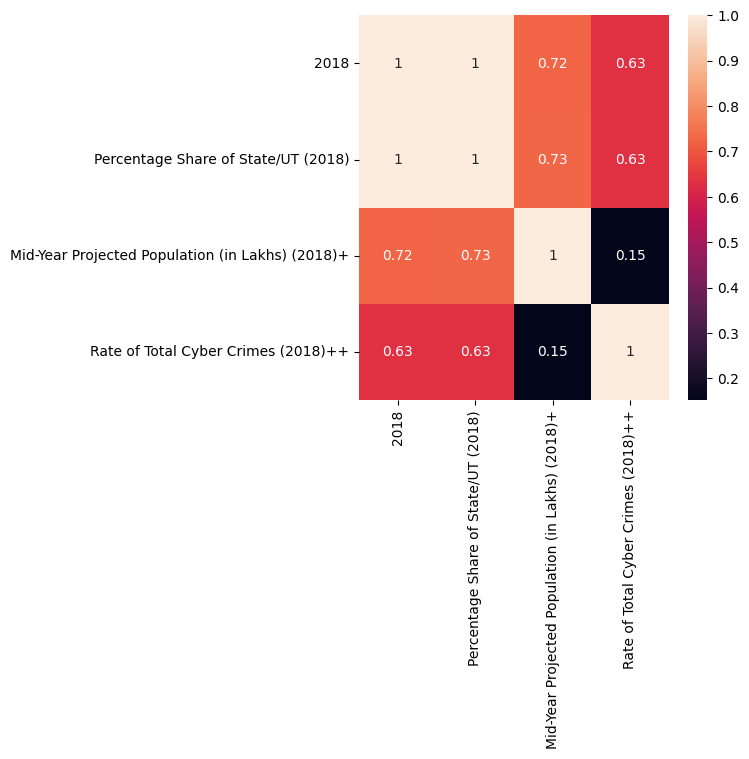

In [ ]:
plt.figure(figsize=(5,5))
sns.heatmap(corr,annot=True)
plt.show()

In [ ]:
cy = cy.drop(columns = ['Percentage Share of State/UT (2018)'])


In [ ]:
#Measures

cy.describe(include = 'all')

,State/UT,2016,2017,2018,Mid-Year Projected Population (in Lakhs) (2018)+,Rate of Total Cyber Crimes (2018)++,State,Union Territory
count,36,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000
unique,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Andhra Pradesh,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,342.138889,605.444444,756.888889,367.605556,1.686111,0.805556,0.194444
std,NaN,602.747147,1102.516536,1481.867678,475.584049,1.881056,0.401386,0.401386
min,NaN,0.000000,0.000000,0.000000,0.700000,0.000000,0.000000,0.000000
25%,NaN,7.000000,9.250000,18.500000,15.200000,0.500000,1.000000,0.000000
50%,NaN,94.000000,166.500000,180.000000,239.800000,1.000000,1.000000,0.000000
75%,NaN,371.750000,606.000000,765.750000,553.850000,2.300000,1.000000,0.000000


In [ ]:
#Skewness

cy[['2016','2017','2018','Mid-Year Projected Population (in Lakhs) (2018)+','Rate of Total Cyber Crimes (2018)++']].skew()

,0
2016,2.854155
2017,2.802707
2018,2.932472
Mid-Year Projected Population (in Lakhs) (2018)+,2.084471
Rate of Total Cyber Crimes (2018)++,2.287935


In [ ]:
#Kurtosis

cy[['2016','2017','2018','Mid-Year Projected Population (in Lakhs) (2018)+','Rate of Total Cyber Crimes (2018)++']].kurt()

,0
2016,8.487988
2017,7.976363
2018,8.422734
Mid-Year Projected Population (in Lakhs) (2018)+,5.642615
Rate of Total Cyber Crimes (2018)++,6.022279


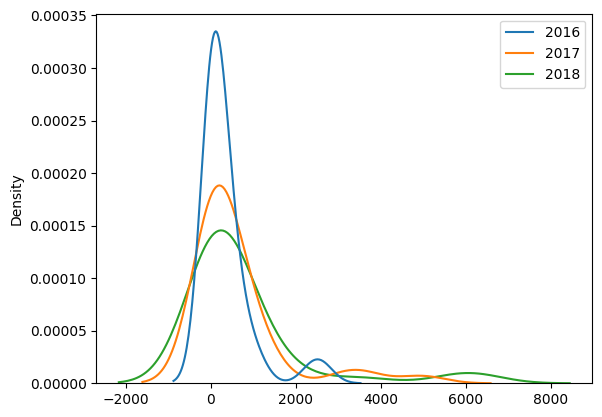

In [ ]:
sns.kdeplot(data=cy[['2016','2017','2018']], cbar = True)
plt.show()

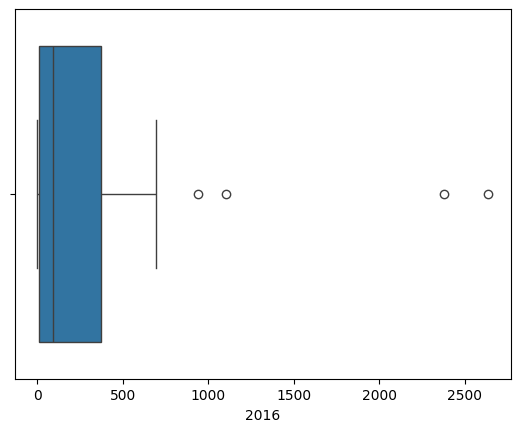

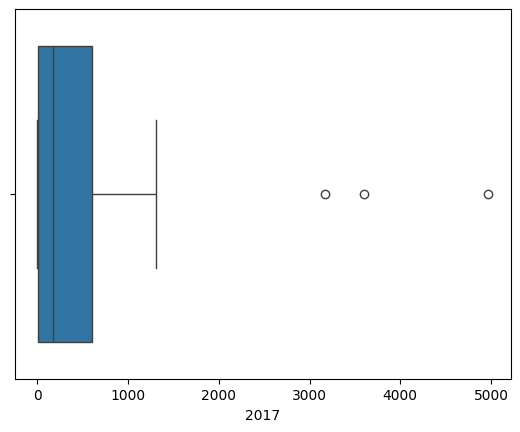

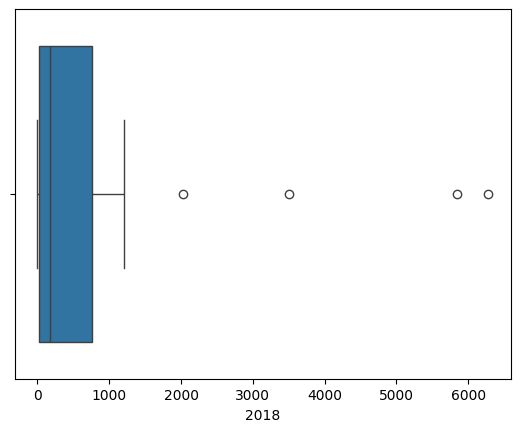

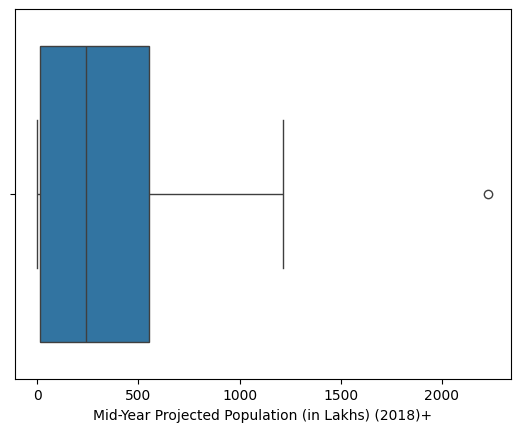

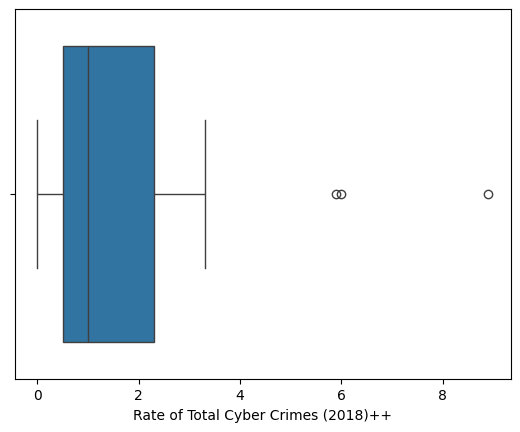

In [ ]:
#To find outliers

col_list = ['2016','2017','2018','Mid-Year Projected Population (in Lakhs) (2018)+','Rate of Total Cyber Crimes (2018)++']
for col in col_list:
    sns.boxplot(data=cy, x=col)
    plt.show()

In [ ]:
#Locate outlier records

Q1 = cy['2016'].quantile(0.25)
Q2 = cy['2016'].quantile(0.50)
Q3 = cy['2016'].quantile(0.75)

IQR = Q3-Q1

LowerFense = Q1 - 1.5 * IQR
HigherFense = Q3 + 1.5 * IQR

print(Q1, Q3, IQR, LowerFense, HigherFense)

7.0 371.75 364.75 -540.125 918.875


In [ ]:
cy[cy['2016'] < LowerFense].shape

(0, 8)

In [ ]:
cy[cy['2016'] > HigherFense].shape

(4, 8)

In [ ]:
#Below 4 records are outliers in 2018 crime count.

cy[cy['2016'] > HigherFense]

,State/UT,2016,2017,2018,Mid-Year Projected Population (in Lakhs) (2018)+,Rate of Total Cyber Crimes (2018)++,State,Union Territory
11,Karnataka,1101,3174,5839,654.5,8.9,1,0
14,Maharashtra,2380,3604,3511,1213.9,2.9,1,0
21,Rajasthan,941,1304,1104,765.9,1.4,1,0
26,Uttar Pradesh,2639,4971,6280,2230.0,2.8,1,0


In [ ]:
#Conversion of column into rows to plot relationship between Crime count VS State

df = cy.set_index(['State/UT','Mid-Year Projected Population (in Lakhs) (2018)+','Rate of Total Cyber Crimes (2018)++','State', 'Union Territory'])\
.stack()\
.reset_index(name='CrimeCount')\
.rename(columns={'level_5':'Year'})

In [ ]:
df = df.drop(columns=['Mid-Year Projected Population (in Lakhs) (2018)+','Rate of Total Cyber Crimes (2018)++','State', 'Union Territory'])

In [ ]:
df.head(10)

,State/UT,Year,CrimeCount
0,Andhra Pradesh,2016,616
1,Andhra Pradesh,2017,931
2,Andhra Pradesh,2018,1207
3,Arunachal Pradesh,2016,4
4,Arunachal Pradesh,2017,1
5,Arunachal Pradesh,2018,7
6,Assam,2016,696
7,Assam,2017,1120
8,Assam,2018,2022
9,Bihar,2016,309


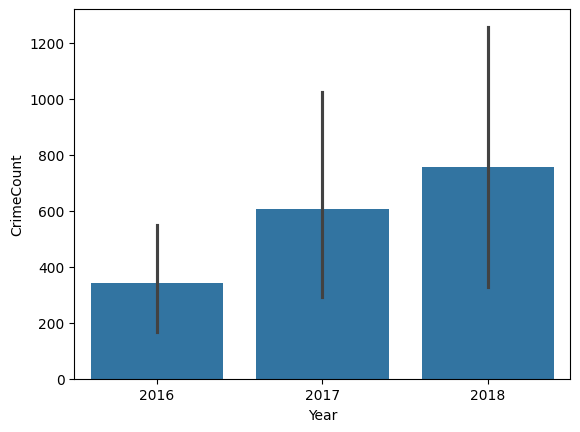

In [ ]:
#Crime count VS Year

sns.barplot(data=df, x='Year', y='CrimeCount')
plt.show()

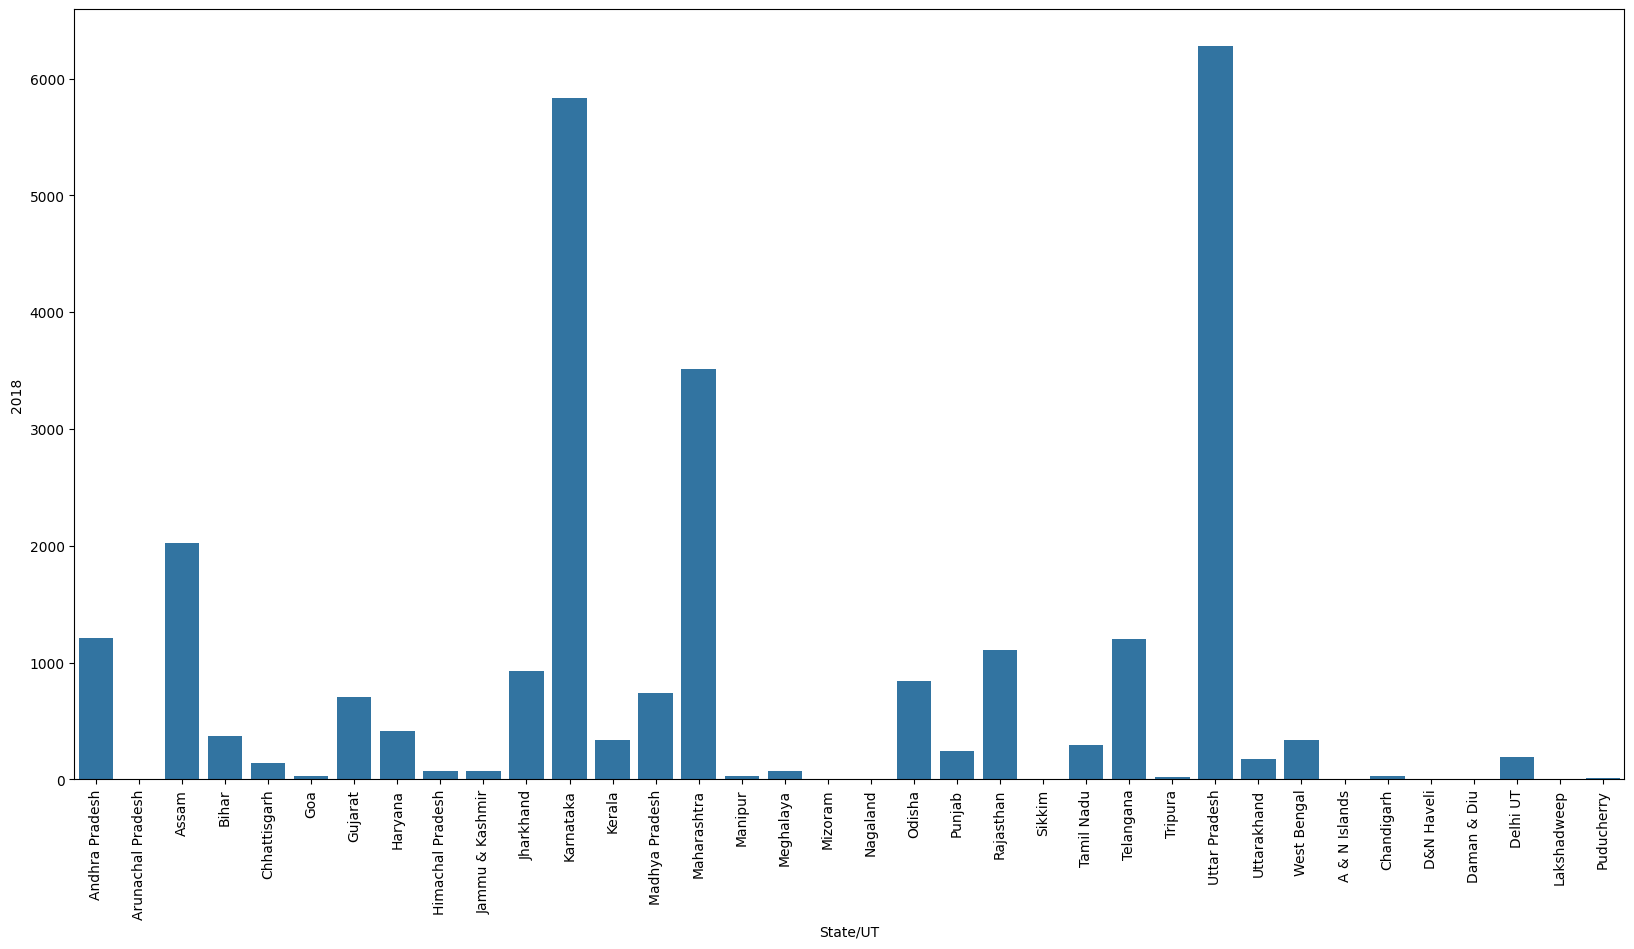

In [ ]:
#2018 crime distribution

plt.figure(figsize=(20,10))
sns.barplot(data=cy, x='State/UT', y='2018')
plt.xticks(rotation = 90)
plt.show()

In [ ]:
max = cy['2018'].max()
cy[cy['2018'] == max]

,State/UT,2016,2017,2018,Mid-Year Projected Population (in Lakhs) (2018)+,Rate of Total Cyber Crimes (2018)++,State,Union Territory
26,Uttar Pradesh,2639,4971,6280,2230.0,2.8,1,0


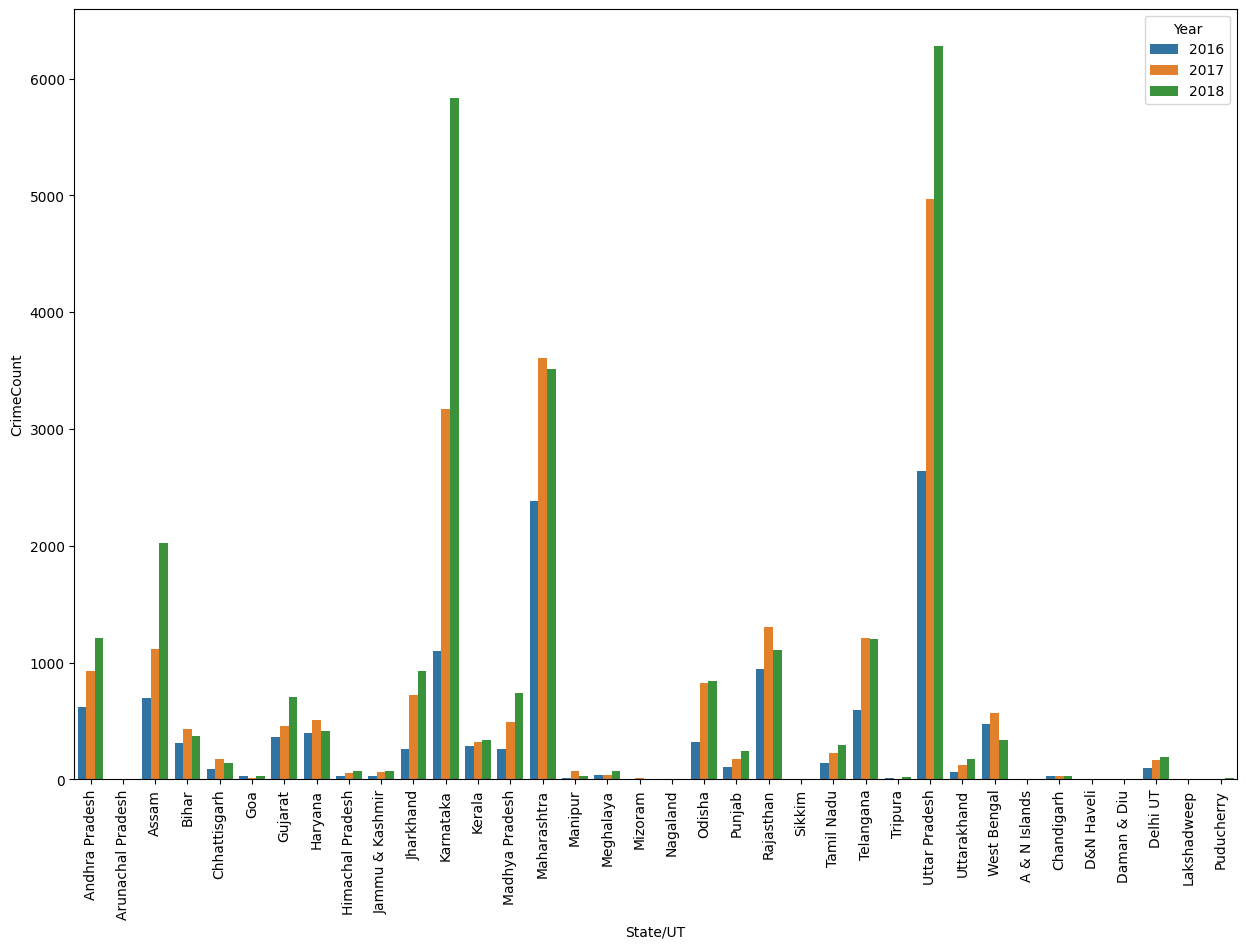

In [ ]:
#Statewise crime count for different years

plt.figure(figsize = (15,10))
sns.barplot(data = df, x='State/UT', y='CrimeCount', hue='Year')
plt.xticks(rotation = 90)
plt.show()

In [ ]:
#Increase in crime count between 2016 & 2018

col = ['State/UT','2016','2017','2018']
df1 = cy[col]
df1['CountIncrease'] = df1['2018'] - df1['2016']
df1.head(10)

<ipython-input-41-59ba733b574e>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['CountIncrease'] = df1['2018'] - df1['2016']


,State/UT,2016,2017,2018,CountIncrease
0,Andhra Pradesh,616,931,1207,591
1,Arunachal Pradesh,4,1,7,3
2,Assam,696,1120,2022,1326
3,Bihar,309,433,374,65
4,Chhattisgarh,90,171,139,49
5,Goa,31,13,29,-2
6,Gujarat,362,458,702,340
7,Haryana,401,504,418,17
8,Himachal Pradesh,31,56,69,38
9,Jammu & Kashmir,28,63,73,45


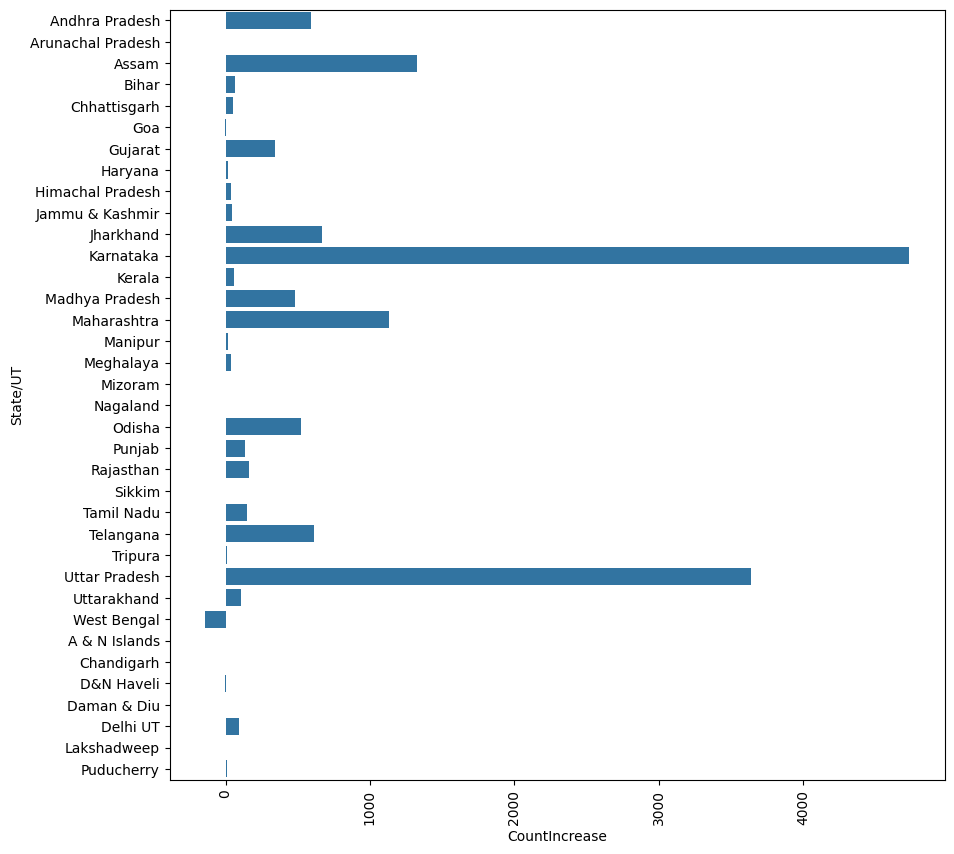

In [ ]:
#Distribution of increase in crime for different states

plt.figure(figsize=(10,10))
sns.barplot(data = df1, x = 'CountIncrease', y = 'State/UT')
plt.xticks(rotation=90)
plt.show()

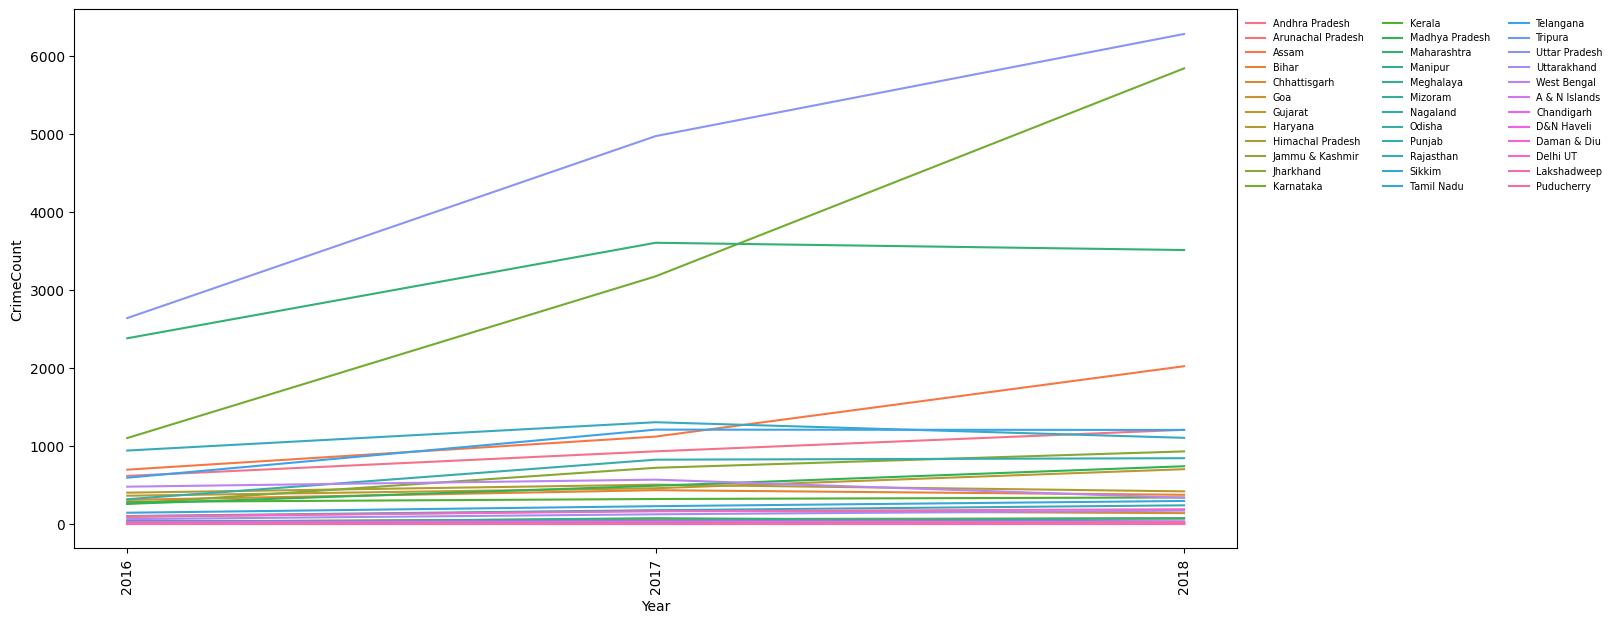

In [ ]:
plt.figure(figsize=(15,7))
sns.lineplot(data = df, x = 'Year', y = 'CrimeCount', hue = 'State/UT')
plt.xticks(rotation=90)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize = 'x-small', frameon = False, ncol=3)
plt.show()

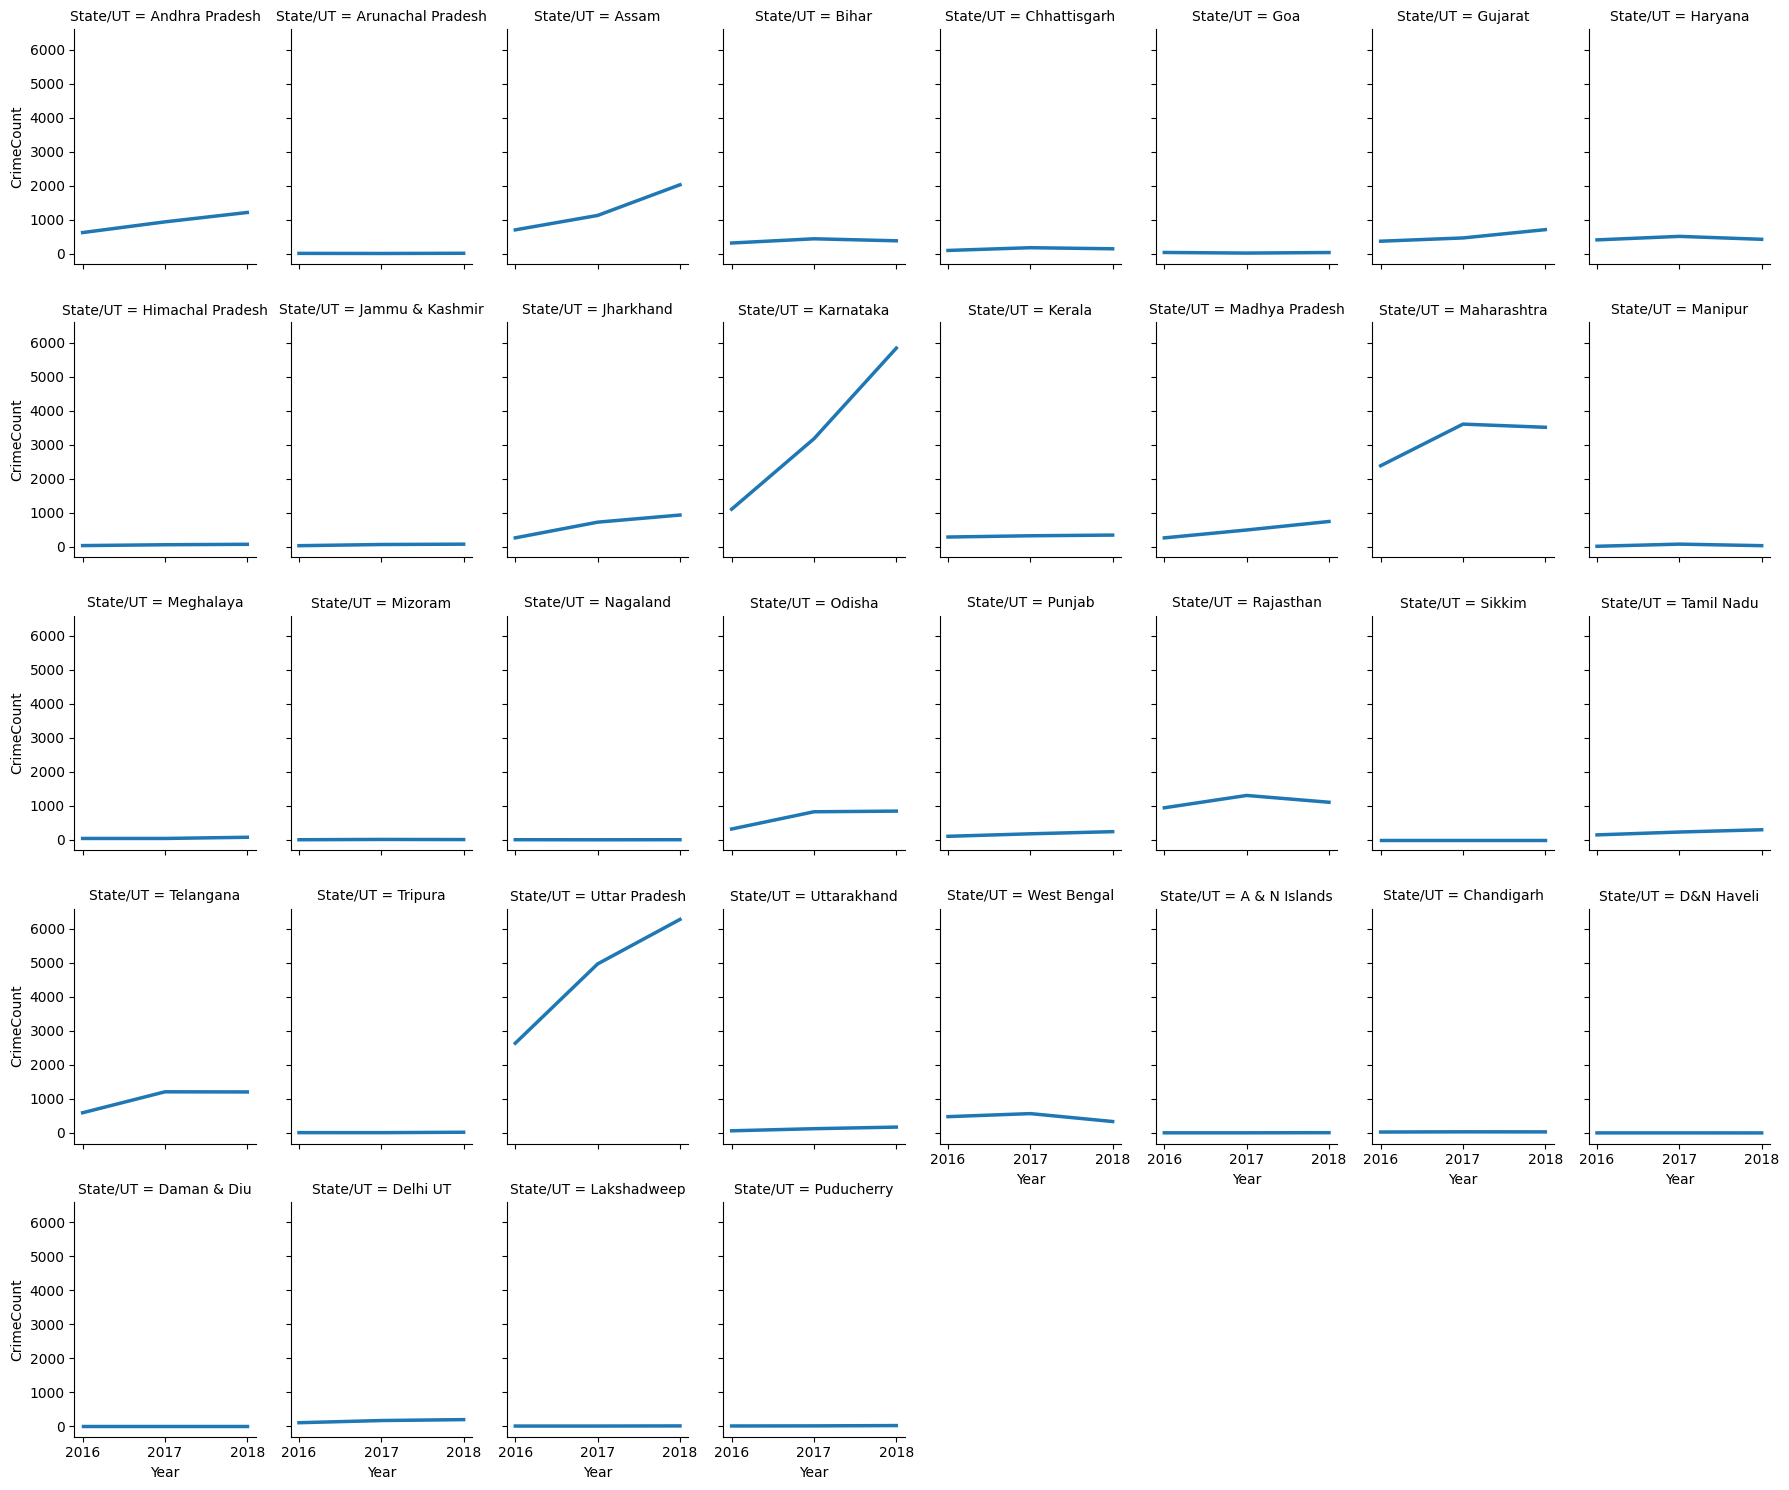

In [ ]:
sns.relplot(data = df, x = 'Year', y = 'CrimeCount', col = 'State/UT',kind='line', col_wrap=8,height=3,aspect=.75,linewidth=2.5)
plt.show()